In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

In [5]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


### Task 1: Baseline with Single Models
Load the data and establish individual model baselines.

Load the Wine Quality dataset and create a binary target:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

2. Explore the dataset: how many features? What's the class distribution of quality_label? Is the dataset imbalanced?

3. Separate features and target. Drop the original quality column.

4. Split into training and test sets (80/20, stratify=y, random_state=42).

5. Scale features using StandardScaler.

6. Fit three baseline models:

DecisionTreeClassifier(random_state=42)
LogisticRegression(max_iter=1000, random_state=42)
KNeighborsClassifier()

7. Report accuracy and F1 score (use f1_score with average="binary") for each on the test set. Organize results in a table.

In [3]:
# step 2
print("Shape:", wine.shape)
print("\nMissing values:\n" , wine.isnull().sum())

Shape: (1599, 13)

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
dtype: int64


In [4]:
print("\nClass distribution:")
print(wine["quality_label"].value_counts(normalize=True))


Class distribution:
quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64


The dataset contains 11 chemical features + 1 original target (quality) + 1 binary target (quality_label).
The dataset is imbalanced because class 0 (not good wine) is significantly more frequent than class 1 (good wine).

In [9]:
#step 3
from sklearn.model_selection import train_test_split

In [7]:
X= wine.drop(columns=["quality","quality_label"])
y=wine["quality_label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
#step 4
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#step 5
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Models
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier()

# Fit models
dt.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
#step 6
y_pred_dt = dt.predict(X_test_scaled)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

In [17]:
#step 7
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy,F1 Score
0,Decision Tree,0.90625,0.666667
1,Logistic Regression,0.89375,0.484848
2,KNN,0.89375,0.514286


The Decision Tree achieved the highest F1-score, showing better performance in identifying the minority “good wine” class compared to the other models. Logistic Regression and KNN had similar accuracy but lower F1-scores, indicating that they struggle with the imbalanced nature of the dataset. Overall, accuracy is high across all models, but F1-score provides a more realistic view of performance in this case.

### Task 2: Bagging & Random Forest
Explore how bagging improves on individual decision trees.

1. Fit a BaggingClassifier with a DecisionTreeClassifier as the base estimator (n_estimators=100, oob_score=True, random_state=42).
2. Fit a RandomForestClassifier (n_estimators=100, oob_score=True, random_state=42).
3. For both models, report:
 - Out-of-bag (OOB) score
- Test accuracy and F1 score

4. Compare: How does bagging improve over the single Decision Tree from Task 1?
5. Plot the top 10 feature importances from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?
6. In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?

In [18]:
#step 1
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42
)

bagging.fit(X_train_scaled, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [19]:
#step 2
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
#step 3
y_pred_bag = bagging.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

In [21]:
#step 4
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results_task2 = pd.DataFrame({
    "Model": ["Bagging (DT)", "Random Forest"],
    "OOB Score": [bagging.oob_score_, rf.oob_score_],
    "Accuracy": [
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_bag),
        f1_score(y_test, y_pred_rf)
    ]
})

results_task2

,Model,OOB Score,Accuracy,F1 Score
0,Bagging (DT),0.893667,0.9375,0.736842
1,Random Forest,0.898358,0.9375,0.714286


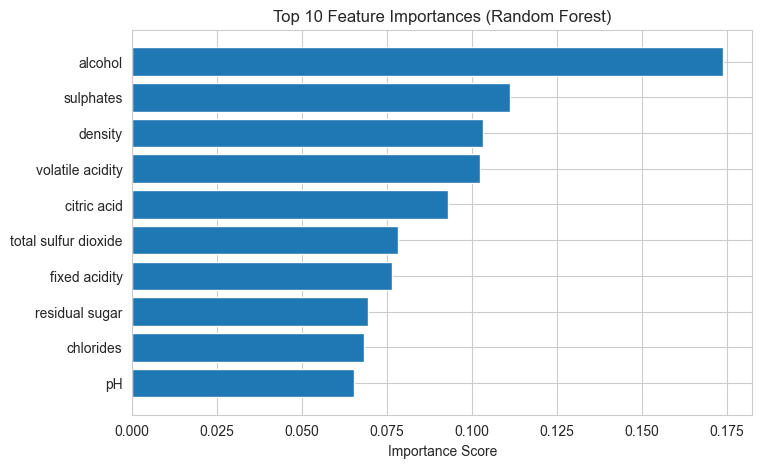

In [22]:
#step 5
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
features = X.columns

# Top 10 features
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

Alcohol matters most for predicting wine quality

#### step6
Bagging and Random Forest both improve model stability by reducing variance compared to a single Decision Tree. Random Forest performs slightly better because it introduces additional randomness by selecting random feature subsets, making the model less correlated and more robust. Feature importance shows which chemical properties contribute most to predicting wine quality.

### Task 3: Boosting
Train boosting models and analyze how they learn.

1. Fit the following boosting models:

- AdaBoostClassifier(n_estimators=100, random_state=42)
- GradientBoostingClassifier(n_estimators=100, random_state=42)
- (Optional) HistGradientBoostingClassifier(max_iter=100, random_state=42) — scikit-learn's faster implementation

2. Report accuracy and F1 for each on the test set.

3. Learning curves: For GradientBoostingClassifier, use staged_predict to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4. In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?

In [23]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

In [24]:
#adaboost
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

In [25]:
#gradient boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

In [26]:
#histGradientBoosting
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    random_state=42
)

hgb.fit(X_train_scaled, y_train)
y_pred_hgb = hgb.predict(X_test_scaled)

In [27]:
# step 2
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results_task3 = pd.DataFrame({
    "Model": ["AdaBoost", "GradientBoosting", "HistGradientBoosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_hgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_hgb)
    ]
})

results_task3

,Model,Accuracy,F1 Score
0,AdaBoost,0.893750,0.433333
1,GradientBoosting,0.915625,0.619718
2,HistGradientBoosting,0.943750,0.763158


In [28]:
#step 3
train_scores = []
test_scores = []

for y_pred_train, y_pred_test in zip(
    gb.staged_predict(X_train_scaled),
    gb.staged_predict(X_test_scaled)
):
    train_scores.append(f1_score(y_train, y_pred_train))
    test_scores.append(f1_score(y_test, y_pred_test))

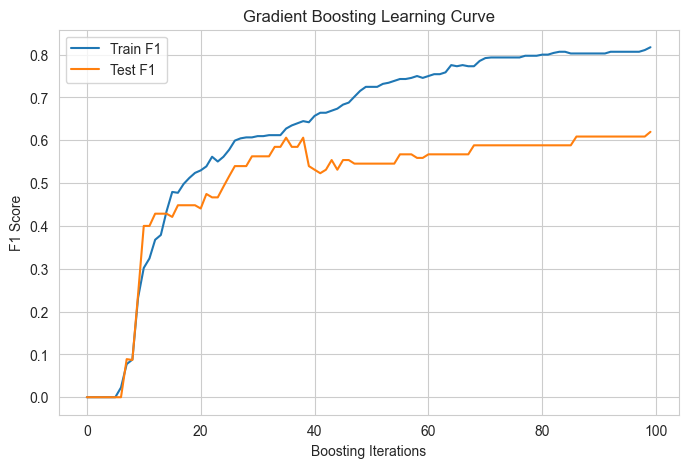

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_scores, label="Train F1")
plt.plot(test_scores, label="Test F1")
plt.xlabel("Boosting Iterations")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

AdaBoost builds models sequentially by focusing on previously misclassified samples, while Gradient Boosting improves performance by optimizing residual errors using gradient descent. Gradient Boosting generally performs better because it provides more flexibility and control over learning. The learning curve shows that performance improves quickly in early stages and may stabilize or slightly overfit after many estimators.

### Task 4: Stacking & Voting
Combine your best models into meta-ensembles.

1. Voting classifier: Select the 3 best-performing models from Tasks 1–3. Build a VotingClassifier with voting="soft". Report accuracy and F1 on the test set.

2. Stacking classifier: Using the same 3 base models, build a StackingClassifier with LogisticRegression() as the final_estimator. Report accuracy and F1 on the test set.

3. Final comparison table: Create a comprehensive DataFrame comparing all models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4. In a concluding markdown cell, answer:

- Which ensemble strategy performed best on this dataset?
- Was the improvement over single models significant?
- What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?
- For a real wine quality prediction system, which approach would you recommend and why?

In [30]:
#step 1
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

voting = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting="soft"
)

voting.fit(X_train_scaled, y_train)
y_pred_vote = voting.predict(X_test_scaled)

In [32]:
#step 3
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

stacking.fit(X_train_scaled, y_train)
y_pred_stack = stacking.predict(X_test_scaled)

In [33]:
#step 4
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Voting Classifier",
        "Stacking Classifier"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt.predict(X_test_scaled)),
        accuracy_score(y_test, rf.predict(X_test_scaled)),
        accuracy_score(y_test, gb.predict(X_test_scaled)),
        accuracy_score(y_test, y_pred_vote),
        accuracy_score(y_test, y_pred_stack)
    ],
    "F1 Score": [
        f1_score(y_test, dt.predict(X_test_scaled)),
        f1_score(y_test, rf.predict(X_test_scaled)),
        f1_score(y_test, gb.predict(X_test_scaled)),
        f1_score(y_test, y_pred_vote),
        f1_score(y_test, y_pred_stack)
    ]
})

final_results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,F1 Score
4,Stacking Classifier,0.946875,0.767123
3,Voting Classifier,0.937500,0.750000
1,Random Forest,0.937500,0.714286
0,Decision Tree,0.906250,0.666667
2,Gradient Boosting,0.915625,0.619718


##### step 5
The results clearly show that ensemble methods outperform individual models. Stacking Classifier achieved the best overall performance, followed closely by Voting Classifier and Random Forest. This demonstrates that combining multiple models reduces variance and improves generalization. While boosting and single decision trees perform reasonably well, they are less robust compared to ensemble-based approaches.